# Neural Network from Scratch with NumPy

This notebook accompanies the post `posts/0.neural-net/neural-net.md`. The goal is to build a small MLP from handwritten building blocks: `Parameter`, `Dense`, `ReLU`, `SoftmaxCrossEntropy`, `Sequential`, and `SGD`.

It uses NumPy only. Each layer caches forward values, computes gradients in `backward()`, and lets the optimizer update each parameter explicitly.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

plt.rcParams.update({
    "figure.figsize": (6, 4),
    "axes.grid": True,
    "grid.alpha": 0.25,
})


## Warm-up: one neuron, dot product, and weighted sum

One neuron can take many input features and still produce one scalar output. In vector form, that output is a dot product between the input vector and the weight vector, then plus one bias.


In [2]:
inputs = np.array([1.0, 2.0, 3.0])
weights = np.array([0.2, 0.8, -0.5])
bias = 2.0

output = inputs @ weights + bias
expanded_output = (
    inputs[0] * weights[0]
    + inputs[1] * weights[1]
    + inputs[2] * weights[2]
    + bias
)

print("dot-product form:", output)
print("expanded weighted sum:", expanded_output)
print("input shape:", inputs.shape)
print("weight shape:", weights.shape)
print("output type:", type(output), "shape:", np.shape(output))


dot-product form: 2.3
expanded weighted sum: 2.3
input shape: (3,)
weight shape: (3,)
output type: <class 'numpy.float64'> shape: ()


## 1. Dataset: 3-class spiral

The spiral dataset is hard for a linear classifier because the classes cannot be separated by one straight line. We standardize the features with train-split statistics so optimization is more stable.


X_train: (288, 2) y_train: (288,)
X_val:   (72, 2) y_val:   (72,)


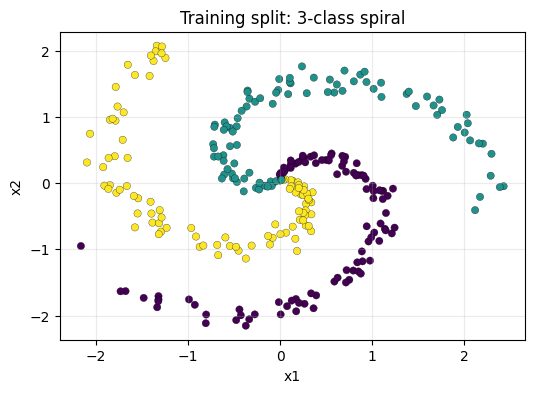

In [3]:
def make_spiral(samples_per_class=120, n_classes=3, noise=0.20, seed=42):
    rng = np.random.default_rng(seed)
    X = np.zeros((samples_per_class * n_classes, 2), dtype=np.float64)
    y = np.zeros(samples_per_class * n_classes, dtype=np.int64)

    for class_id in range(n_classes):
        ix = slice(class_id * samples_per_class, (class_id + 1) * samples_per_class)
        r = np.linspace(0.0, 1.0, samples_per_class)
        t = np.linspace(class_id * 4.0, (class_id + 1) * 4.0, samples_per_class)
        t = t + rng.normal(0.0, noise, samples_per_class)
        X[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
        y[ix] = class_id

    return X, y


def train_val_split(X, y, val_ratio=0.20, seed=7):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(X))
    split = int((1.0 - val_ratio) * len(X))
    train_idx, val_idx = idx[:split], idx[split:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


def standardize(train_X, val_X):
    mean = train_X.mean(axis=0, keepdims=True)
    std = train_X.std(axis=0, keepdims=True) + 1e-8
    return (train_X - mean) / std, (val_X - mean) / std


X, y = make_spiral(seed=42)
X_train_raw, y_train, X_val_raw, y_val = train_val_split(X, y, seed=7)
X_train, X_val = standardize(X_train_raw, X_val_raw)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "y_val:  ", y_val.shape)

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="viridis", s=28, edgecolor="k", linewidth=0.2)
plt.title("Training split: 3-class spiral")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()


## 2. Parameters and layers

`Parameter` stores both `value` and `grad`. Layers with trainable arrays return them through `parameters()`, while layers without parameters such as `ReLU` return an empty list.


In [4]:
class Parameter:
    """Trainable array plus its gradient."""

    def __init__(self, value):
        self.value = np.asarray(value, dtype=np.float64)
        self.grad = np.zeros_like(self.value)

    def zero_grad(self):
        self.grad.fill(0.0)


class Dense:
    """Fully-connected layer: y = x @ W + b."""

    def __init__(self, n_in, n_out, rng, init="he"):
        if init == "he":
            scale = np.sqrt(2.0 / n_in)
        elif init == "xavier":
            scale = np.sqrt(1.0 / n_in)
        else:
            raise ValueError(f"unknown init: {init}")

        self.W = Parameter(rng.normal(0.0, scale, size=(n_in, n_out)))
        self.b = Parameter(np.zeros((1, n_out)))

    def forward(self, x, training=True):
        self.x = x
        return x @ self.W.value + self.b.value

    def backward(self, dout):
        self.W.grad[...] = self.x.T @ dout
        self.b.grad[...] = dout.sum(axis=0, keepdims=True)
        return dout @ self.W.value.T

    def parameters(self):
        return [self.W, self.b]


class ReLU:
    """Element-wise nonlinearity: max(0, x)."""

    def forward(self, x, training=True):
        self.mask = x > 0
        return np.maximum(0.0, x)

    def backward(self, dout):
        return dout * self.mask

    def parameters(self):
        return []


class Dropout:
    """Inverted dropout. Active during training, identity during eval."""

    def __init__(self, p=0.1, rng=None):
        if not 0.0 <= p < 1.0:
            raise ValueError("p must be in [0, 1).")
        self.p = p
        self.rng = rng or np.random.default_rng()

    def forward(self, x, training=True):
        if (not training) or self.p == 0.0:
            self.mask = np.ones_like(x)
            return x

        keep_prob = 1.0 - self.p
        self.mask = (self.rng.random(x.shape) < keep_prob) / keep_prob
        return x * self.mask

    def backward(self, dout):
        return dout * self.mask

    def parameters(self):
        return []


class LayerNorm:
    """LayerNorm over the last dimension for 2D tensors [B, H]."""

    def __init__(self, n_features, eps=1e-5):
        self.eps = eps
        self.gamma = Parameter(np.ones((1, n_features)))
        self.beta = Parameter(np.zeros((1, n_features)))

    def forward(self, x, training=True):
        self.mu = x.mean(axis=1, keepdims=True)
        self.var = ((x - self.mu) ** 2).mean(axis=1, keepdims=True)
        self.std_inv = 1.0 / np.sqrt(self.var + self.eps)
        self.x_hat = (x - self.mu) * self.std_inv
        return self.gamma.value * self.x_hat + self.beta.value

    def backward(self, dout):
        _, n_features = dout.shape
        self.gamma.grad[...] = (dout * self.x_hat).sum(axis=0, keepdims=True)
        self.beta.grad[...] = dout.sum(axis=0, keepdims=True)

        dx_hat = dout * self.gamma.value
        dx = (self.std_inv / n_features) * (
            n_features * dx_hat
            - dx_hat.sum(axis=1, keepdims=True)
            - self.x_hat * (dx_hat * self.x_hat).sum(axis=1, keepdims=True)
        )
        return dx

    def parameters(self):
        return [self.gamma, self.beta]


## 3. Loss, model wrapper, optimizer

`SoftmaxCrossEntropy` combines softmax and cross-entropy because the gradient with respect to the logits simplifies nicely to `(probs - one_hot(y)) / B`.


In [5]:
class SoftmaxCrossEntropy:
    def forward(self, logits, y):
        shifted = logits - logits.max(axis=1, keepdims=True)
        exp_scores = np.exp(shifted)
        self.probs = exp_scores / exp_scores.sum(axis=1, keepdims=True)
        self.y = y

        correct_probs = self.probs[np.arange(y.size), y]
        return -np.log(correct_probs + 1e-12).mean()

    def backward(self):
        grad = self.probs.copy()
        grad[np.arange(self.y.size), self.y] -= 1.0
        grad /= self.y.size
        return grad


class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, x, training=True):
        for layer in self.layers:
            x = layer.forward(x, training=training)
        return x

    def backward(self, grad):
        for layer in reversed(self.layers):
            grad = layer.backward(grad)
        return grad

    def parameters(self):
        params = []
        for layer in self.layers:
            params.extend(layer.parameters())
        return params

    def zero_grad(self):
        for param in self.parameters():
            param.zero_grad()


class SGD:
    def __init__(self, lr=0.75):
        self.lr = lr

    def step(self, params):
        for param in params:
            param.value -= self.lr * param.grad


def accuracy(model, X, y):
    logits = model.forward(X, training=False)
    preds = logits.argmax(axis=1)
    return (preds == y).mean()


## 4. Shape and gradient checks

The shape check catches bad matrix multiplies. The finite-difference check probes one element of `W.grad` to confirm that `Dense.backward()` is using the correct orientation.


In [6]:
debug_rng = np.random.default_rng(0)
debug_model = Sequential([
    Dense(2, 5, debug_rng),
    ReLU(),
    Dense(5, 3, debug_rng, init="xavier"),
])

debug_loss = SoftmaxCrossEntropy()
debug_logits = debug_model.forward(X_train[:4], training=True)
debug_value = debug_loss.forward(debug_logits, y_train[:4])
debug_model.zero_grad()
debug_model.backward(debug_loss.backward())

print("logits shape:", debug_logits.shape)
print("loss:", debug_value)

for param in debug_model.parameters():
    print("param", param.value.shape, "grad", param.grad.shape)
    assert param.value.shape == param.grad.shape


def check_dense_gradient(eps=1e-5):
    rng = np.random.default_rng(1)
    layer = Dense(4, 3, rng, init="xavier")
    x = rng.normal(size=(5, 4))
    dout = rng.normal(size=(5, 3))

    layer.forward(x)
    layer.backward(dout)

    index = (0, 0)
    original = layer.W.value[index]

    layer.W.value[index] = original + eps
    loss_pos = (layer.forward(x) * dout).sum()

    layer.W.value[index] = original - eps
    loss_neg = (layer.forward(x) * dout).sum()

    layer.W.value[index] = original
    numeric_grad = (loss_pos - loss_neg) / (2 * eps)
    analytic_grad = layer.W.grad[index]

    print(f"analytic dW{index}: {analytic_grad:.6f}")
    print(f"numeric  dW{index}: {numeric_grad:.6f}")
    assert np.allclose(analytic_grad, numeric_grad, rtol=1e-5, atol=1e-7)


check_dense_gradient()


logits shape: (4, 3)
loss: 0.9446256575140051
param (2, 5) grad (2, 5)
param (1, 5) grad (1, 5)
param (5, 3) grad (5, 3)
param (1, 3) grad (1, 3)
analytic dW(0, 0): 2.137134
numeric  dW(0, 0): 2.137134


## 5. Linear baseline, then MLP

Train the linear baseline first to expose the failure mode: one Dense layer can only draw a straight boundary. Then train the `2 -> 64 -> 3` MLP to see how ReLU creates a curved boundary.


In [7]:
def fit(model, X_train, y_train, X_val, y_val, epochs=2000, lr=0.75, log_every=100, name=None):
    if name:
        print(f"\n{name}")

    loss_fn = SoftmaxCrossEntropy()
    optimizer = SGD(lr=lr)
    history = {"epoch": [], "loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs + 1):
        logits = model.forward(X_train, training=True)
        loss = loss_fn.forward(logits, y_train)

        model.zero_grad()
        model.backward(loss_fn.backward())
        optimizer.step(model.parameters())

        if epoch % log_every == 0:
            train_acc = accuracy(model, X_train, y_train)
            val_acc = accuracy(model, X_val, y_val)
            history["epoch"].append(epoch)
            history["loss"].append(loss)
            history["train_acc"].append(train_acc)
            history["val_acc"].append(val_acc)
            print(f"epoch {epoch:4d} | loss {loss:.4f} | train {train_acc:.3f} | val {val_acc:.3f}")

    return history


linear_model = Sequential([
    Dense(2, 3, np.random.default_rng(100), init="xavier"),
])

linear_history = fit(
    linear_model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=500,
    lr=0.5,
    log_every=100,
    name="Linear baseline: Dense(2, 3)",
)

model = Sequential([
    Dense(2, 64, np.random.default_rng(101), init="he"),
    ReLU(),
    Dense(64, 3, np.random.default_rng(102), init="xavier"),
])

history = fit(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=2000,
    lr=0.75,
    log_every=100,
    name="MLP: Dense(2, 64) -> ReLU -> Dense(64, 3)",
)



Linear baseline: Dense(2, 3)
epoch    0 | loss 1.8818 | train 0.045 | val 0.069
epoch  100 | loss 0.7126 | train 0.545 | val 0.486
epoch  200 | loss 0.7125 | train 0.545 | val 0.486
epoch  300 | loss 0.7125 | train 0.545 | val 0.486
epoch  400 | loss 0.7125 | train 0.545 | val 0.486
epoch  500 | loss 0.7125 | train 0.545 | val 0.486

MLP: Dense(2, 64) -> ReLU -> Dense(64, 3)
epoch    0 | loss 1.5785 | train 0.458 | val 0.361
epoch  100 | loss 0.1252 | train 0.983 | val 0.986
epoch  200 | loss 0.0762 | train 0.990 | val 0.972
epoch  300 | loss 0.0587 | train 0.993 | val 0.986
epoch  400 | loss 0.0498 | train 0.993 | val 0.986
epoch  500 | loss 0.0441 | train 0.993 | val 0.986
epoch  600 | loss 0.0401 | train 0.993 | val 0.986
epoch  700 | loss 0.0371 | train 0.993 | val 0.986
epoch  800 | loss 0.0348 | train 0.997 | val 0.986
epoch  900 | loss 0.0329 | train 0.997 | val 0.986
epoch 1000 | loss 0.0313 | train 0.997 | val 0.986
epoch 1100 | loss 0.0300 | train 0.997 | val 0.986
epoch 120

## 6. Loss curve and accuracy

The linear baseline lowers the loss a little, but it is limited by the shape of its boundary. The MLP drives the loss much lower because the hidden ReLU layer can bend the decision regions.


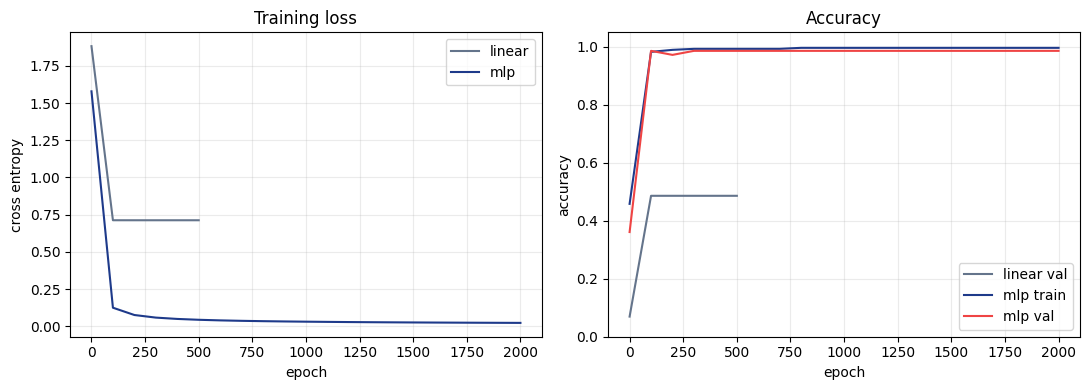

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(linear_history["epoch"], linear_history["loss"], label="linear", color="#64748B")
axes[0].plot(history["epoch"], history["loss"], label="mlp", color="#1E3A8A")
axes[0].set_title("Training loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("cross entropy")
axes[0].legend()

axes[1].plot(linear_history["epoch"], linear_history["val_acc"], label="linear val", color="#64748B")
axes[1].plot(history["epoch"], history["train_acc"], label="mlp train", color="#1E3A8A")
axes[1].plot(history["epoch"], history["val_acc"], label="mlp val", color="#EF4444")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].set_ylim(0.0, 1.05)
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Decision boundary

The decision boundary is the clearest visual summary. The linear baseline splits the plane with straight lines, while the MLP stitches together many ReLU regions into curved areas around the spiral.


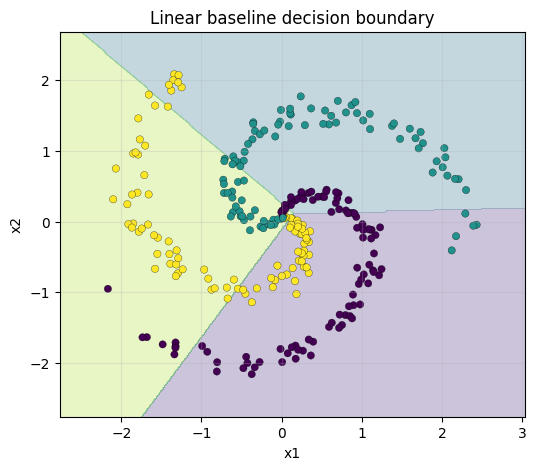

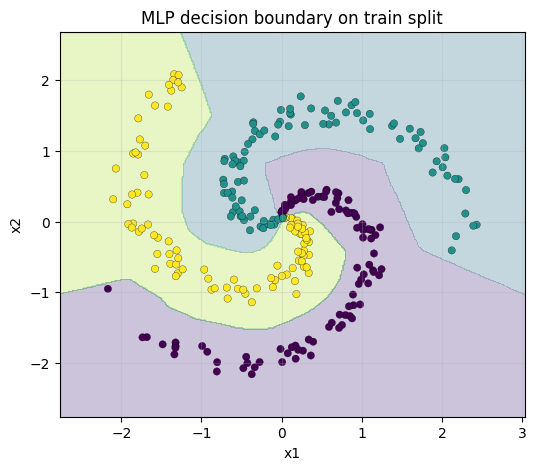

linear train accuracy: 0.5451388888888888
linear val accuracy:   0.4861111111111111
mlp train accuracy:    0.9965277777777778
mlp val accuracy:      0.9861111111111112


In [9]:
def plot_decision_boundary(model, X_points, y_points, title="Decision boundary"):
    pad = 0.6
    x_min, x_max = X_points[:, 0].min() - pad, X_points[:, 0].max() + pad
    y_min, y_max = X_points[:, 1].min() - pad, X_points[:, 1].max() + pad
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 350),
        np.linspace(y_min, y_max, 350),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.forward(grid, training=False).argmax(axis=1).reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, preds, levels=3, alpha=0.28, cmap="viridis")
    plt.scatter(X_points[:, 0], X_points[:, 1], c=y_points, cmap="viridis", s=28, edgecolor="k", linewidth=0.2)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()


plot_decision_boundary(linear_model, X_train, y_train, title="Linear baseline decision boundary")
plot_decision_boundary(model, X_train, y_train, title="MLP decision boundary on train split")

print("linear train accuracy:", accuracy(linear_model, X_train, y_train))
print("linear val accuracy:  ", accuracy(linear_model, X_val, y_val))
print("mlp train accuracy:   ", accuracy(model, X_train, y_train))
print("mlp val accuracy:     ", accuracy(model, X_val, y_val))


## 8. Optional: adding Dropout or LayerNorm

`Dropout` and `LayerNorm` are already implemented above. For a first pass, run the main model first. After that, swap in one of the two variants below for follow-up discussion and Q&A.


In [10]:
dropout_model = Sequential([
    Dense(2, 64, np.random.default_rng(201), init="he"),
    ReLU(),
    Dropout(p=0.10, rng=np.random.default_rng(202)),
    Dense(64, 3, np.random.default_rng(203), init="xavier"),
])

norm_model = Sequential([
    Dense(2, 64, np.random.default_rng(301), init="he"),
    LayerNorm(64),
    ReLU(),
    Dense(64, 3, np.random.default_rng(302), init="xavier"),
])

print("Optional models are constructed. Train them with fit(dropout_model, ...) or fit(norm_model, ...).")


Optional models are constructed. Train them with fit(dropout_model, ...) or fit(norm_model, ...).


## Takeaways

- `Parameter` makes the learning target explicit: each trainable array has a `value` and a `grad`.
- `Dense.backward()` must return `dx`, not just compute `dW` and `db`.
- `SoftmaxCrossEntropy.backward()` returns the compact gradient `(probs - one_hot(y)) / B`.
- `Sequential.backward()` is just backward execution in reverse order.
- `SGD.step()` does not know anything about neural networks; it only updates each parameter.
